# Marketing Analytics - Caso 1: Ecommerce Max

# Pregunta 1

In [154]:
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
from scipy import stats


# Parte 1

## 1.1

In [136]:
# Cargar dataset
df = pd.read_csv("ab_test_data.csv")

# Vista general
print(df.head())
print(df.info())
print(df.describe())


   user_id  age gender  treatment  converted          datetime  \
0        1   39   male          1          0  2025-06-02 08:50   
1        2   33   male          1          0  2025-06-01 08:00   
2        3   41   male          0          0  2025-06-06 08:47   
3        4   50   male          1          0  2025-06-03 11:22   
4        5   32   male          1          0  2025-06-03 22:09   

   distance_to_store  
0              1.109  
1              4.916  
2              4.978  
3              3.088  
4              1.018  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3752 entries, 0 to 3751
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            3752 non-null   int64  
 1   age                3752 non-null   int64  
 2   gender             3752 non-null   object 
 3   treatment          3752 non-null   int64  
 4   converted          3752 non-null   int64  
 5   datetime          

In [137]:
total_usuarios = df['user_id'].nunique()
print(f"Total de usuarios únicos: {total_usuarios}")


Total de usuarios únicos: 3752


In [138]:
tasa_conversion = df['converted'].mean()
print(f"Tasa general de conversión: {tasa_conversion:.2%}")


Tasa general de conversión: 14.85%


In [139]:
distrib_treatment = df['treatment'].value_counts(normalize=True)
print(distrib_treatment)


treatment
0    0.512793
1    0.487207
Name: proportion, dtype: float64


## 1.2

In [140]:
conversion_rates = df.groupby('treatment')['converted'].mean()
print(conversion_rates)


treatment
0    0.126299
1    0.171772
Name: converted, dtype: float64


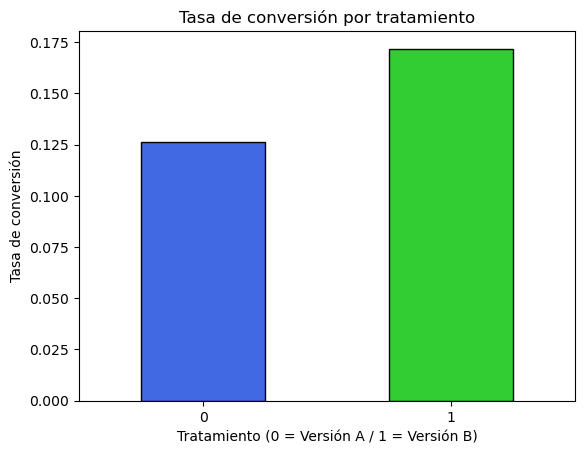

In [141]:
conversion_rates.plot(
    kind='bar',
    color=['royalblue', 'limegreen'],
    edgecolor='black'
)
plt.title('Tasa de conversión por tratamiento')
plt.xlabel('Tratamiento (0 = Versión A / 1 = Versión B)')
plt.ylabel('Tasa de conversión')
plt.xticks(rotation=0)
plt.show()


# Parte 2

## 2.1

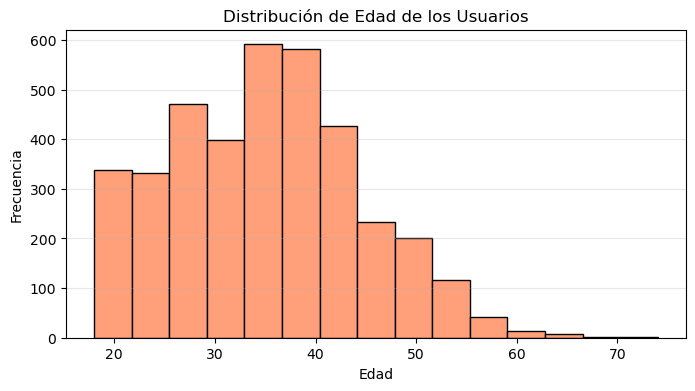

In [142]:
plt.figure(figsize=(8,4))
plt.hist(df['age'], bins=15, color='lightsalmon', edgecolor='black')
plt.title('Distribución de Edad de los Usuarios')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)
plt.show()


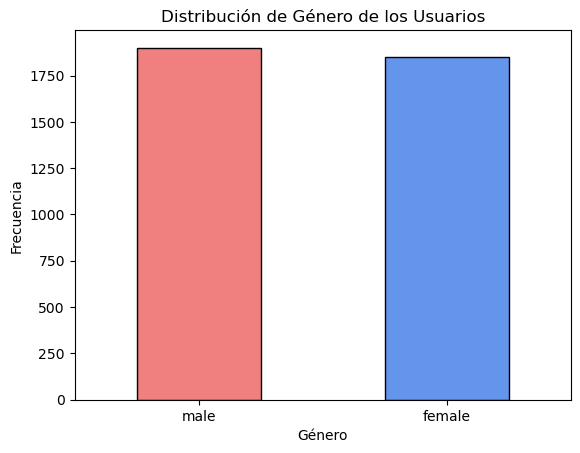

In [143]:
df['gender'].value_counts().plot(
    kind='bar',
    color=['lightcoral', 'cornflowerblue'],
    edgecolor='black'
)
plt.title('Distribución de Género de los Usuarios')
plt.xlabel('Género')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.show()


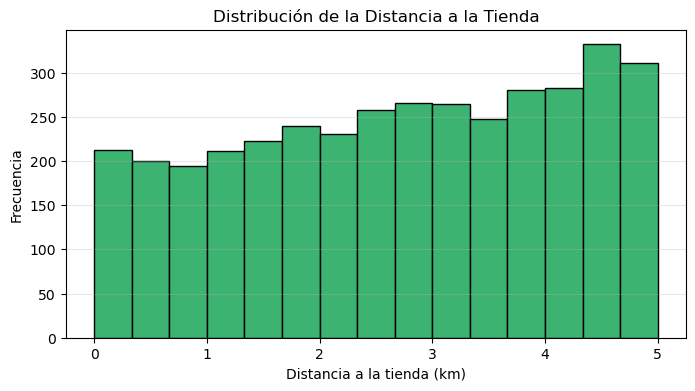

In [144]:
plt.figure(figsize=(8,4))
plt.hist(df['distance_to_store'], bins=15, color='mediumseagreen', edgecolor='black')
plt.title('Distribución de la Distancia a la Tienda')
plt.xlabel('Distancia a la tienda (km)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)
plt.show()


## 2.2

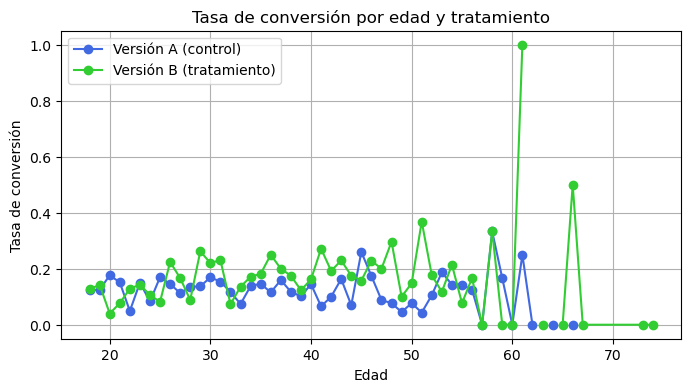

In [ ]:
# Promedio de conversión agrupado por edad y tratamiento
conv_edad_trat = df.groupby(['age', 'treatment'])['converted'].mean().unstack()

# Gráfico
conv_edad_trat.plot(
    kind='line', 
    marker='o', 
    figsize=(8,4), 
    color=['royalblue', 'limegreen']
)
plt.title('Tasa de conversión por edad y tratamiento')
plt.xlabel('Edad')
plt.ylabel('Tasa de conversión')
plt.legend(['Versión A (control)', 'Versión B (tratamiento)'])
plt.grid(True)
plt.show()


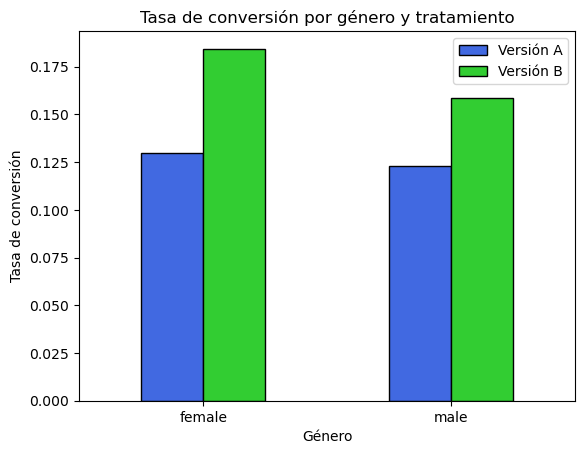

In [146]:
conv_genero_trat = df.groupby(['gender', 'treatment'])['converted'].mean().unstack()

conv_genero_trat.plot(
    kind='bar',
    color=['royalblue', 'limegreen'],
    edgecolor='black'
)
plt.title('Tasa de conversión por género y tratamiento')
plt.xlabel('Género')
plt.ylabel('Tasa de conversión')
plt.legend(['Versión A', 'Versión B'])
plt.xticks(rotation=0)
plt.show()


C:\Users\Javier Trincado\AppData\Local\Temp\ipykernel_28016\2480443259.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conv_dist_trat = df.groupby(['distancia_grupo', 'treatment'])['converted'].mean().unstack()


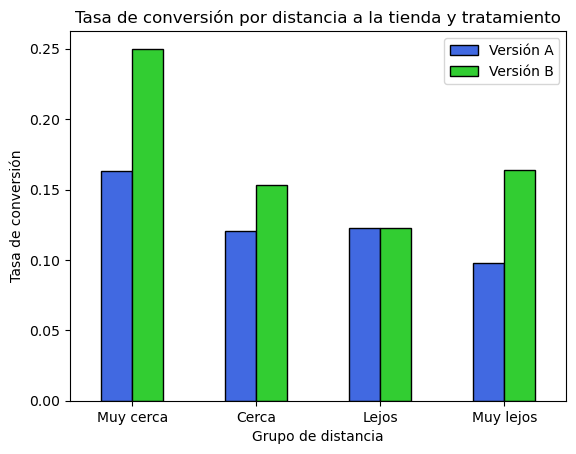

In [147]:
# Agrupar por cuartiles de distancia
df['distancia_grupo'] = pd.qcut(df['distance_to_store'], 4, labels=['Muy cerca', 'Cerca', 'Lejos', 'Muy lejos'])

conv_dist_trat = df.groupby(['distancia_grupo', 'treatment'])['converted'].mean().unstack()

conv_dist_trat.plot(
    kind='bar',
    color=['royalblue', 'limegreen'],
    edgecolor='black'
)
plt.title('Tasa de conversión por distancia a la tienda y tratamiento')
plt.xlabel('Grupo de distancia')
plt.ylabel('Tasa de conversión')
plt.legend(['Versión A', 'Versión B'])
plt.xticks(rotation=0)
plt.show()


#  Parte 3

## 3.1

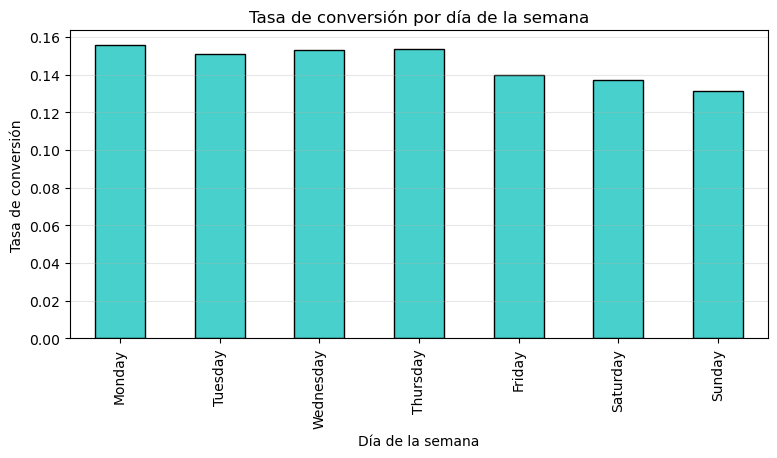

In [ ]:
# Crear columna con el nombre del día
df['day_of_week'] = pd.to_datetime(df['datetime']).dt.day_name()

# Calcular la tasa de conversión promedio por día
conv_dia = df.groupby('day_of_week')['converted'].mean().reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
])

# Gráfico de barras
plt.figure(figsize=(9,4))
conv_dia.plot(kind='bar', color='mediumturquoise', edgecolor='black')
plt.title('Tasa de conversión por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Tasa de conversión')
plt.grid(axis='y', alpha=0.3)
plt.show()


# Parte 4

## 4.1

In [ ]:
# Separar grupos
grupo_A = df[df['treatment'] == 0]['converted']
grupo_B = df[df['treatment'] == 1]['converted']

# Calcular el test t para muestras independientes
t_stat, p_value = stats.ttest_ind(grupo_A, grupo_B, equal_var=False)

print(f"Estadístico t: {t_stat:.4f}")
print(f"P-valor: {p_value:.4f}")


Estadístico t: -3.9100
P-valor: 0.0001


# Parte 5

## 5.1

In [ ]:
# Definir variables
X = df['treatment']              # Variable independiente (0 = A, 1 = B)
y = df['converted']              # Variable dependiente (0 o 1)

# Agregar constante para el intercepto
X = sm.add_constant(X)

# Ajustar el modelo
modelo = sm.OLS(y, X).fit()

# Mostrar resumen de la regresión
print(modelo.summary())


                            OLS Regression Results                            
Dep. Variable:              converted   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     15.39
Date:                Tue, 14 Oct 2025   Prob (F-statistic):           8.91e-05
Time:                        23:00:54   Log-Likelihood:                -1436.3
No. Observations:                3752   AIC:                             2877.
Df Residuals:                    3750   BIC:                             2889.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1263      0.008     15.609      0.0

## 5.2

In [ ]:
# Categorías de edad
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 29, 39, 49, 59, 100],
    labels=['<30', '30-40', '40-50', '50-60', '60+']
)

# Crear variables dummy (sin eliminar referencia todavía)
age_dummies = pd.get_dummies(df['age_group'], prefix='age')

# Variable dummy para género
df['gender_female'] = (df['gender'] == 'female').astype(int)

# Variables dummy para día de la semana
df['day_of_week'] = pd.to_datetime(df['datetime']).dt.day_name()
day_dummies = pd.get_dummies(df['day_of_week'], prefix='day')

# Combinar todo
df_extended = pd.concat([df, age_dummies, day_dummies], axis=1)

# Mostrar verificación
print(df_extended.head())
print("\nColumnas creadas:\n", df_extended.columns)



   user_id  age gender  treatment  converted          datetime  \
0        1   39   male          1          0  2025-06-02 08:50   
1        2   33   male          1          0  2025-06-01 08:00   
2        3   41   male          0          0  2025-06-06 08:47   
3        4   50   male          1          0  2025-06-03 11:22   
4        5   32   male          1          0  2025-06-03 22:09   

   distance_to_store distancia_grupo day_of_week age_group  ...  age_40-50  \
0              1.109       Muy cerca      Monday     30-40  ...      False   
1              4.916       Muy lejos      Sunday     30-40  ...      False   
2              4.978       Muy lejos      Friday     40-50  ...       True   
3              3.088           Lejos     Tuesday     50-60  ...      False   
4              1.018       Muy cerca     Tuesday     30-40  ...      False   

   age_50-60  age_60+  day_Friday  day_Monday  day_Saturday  day_Sunday  \
0      False    False       False        True         False

## 5.3

In [ ]:
# --- 1) Seleccionar SOLO dummies válidas (excluir columnas textuales) ---
day_dummy_cols = [c for c in df_extended.columns if c.startswith('day_') and c != 'day_of_week']
age_dummy_cols = [c for c in df_extended.columns if c.startswith('age_') and c != 'age_group']

# --- 2) Elegir referencias---
ref_age = 'age_<30'
ref_day = 'day_Friday'
if ref_age not in age_dummy_cols:
    ref_age = None
if ref_day not in day_dummy_cols:
    ref_day = None

age_vars = [c for c in age_dummy_cols if c != ref_age]
day_vars = [c for c in day_dummy_cols if c != ref_day]

# --- 3) Asegurar tipos NUMÉRICOS en todas las columnas de X e y ---
for c in (age_vars + day_vars + ['gender_female']):
    df_extended[c] = df_extended[c].astype(int)

df_extended['treatment'] = df_extended['treatment'].astype(int)
df_extended['distance_to_store'] = df_extended['distance_to_store'].astype(float)
df_extended['converted'] = df_extended['converted'].astype(int)

# --- 4) Construir matrices y ajustar el modelo extendido (5.3) ---
X = df_extended[['treatment', 'gender_female', 'distance_to_store'] + age_vars + day_vars]
y = df_extended['converted']

X = sm.add_constant(X)
modelo_ext = sm.OLS(y, X).fit()
print(modelo_ext.summary())



                            OLS Regression Results                            
Dep. Variable:              converted   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     3.951
Date:                Tue, 14 Oct 2025   Prob (F-statistic):           1.94e-06
Time:                        23:00:54   Log-Likelihood:                -1418.3
No. Observations:                3752   AIC:                             2865.
Df Residuals:                    3738   BIC:                             2952.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.1550      0.02

# Parte 6

## 6.1

In [153]:
# ===========================
# Modelo simple (solo treatment)
# ===========================
X_simple = sm.add_constant(df['treatment'])
y = df['converted']

modelo_simple = sm.OLS(y, X_simple).fit()

# ===========================
# Modelo extendido (con controles)
# ===========================
X_extended = df_extended[[
    'treatment',
    'gender_female',
    'distance_to_store',
    'age_30-40', 'age_40-50', 'age_50-60', 'age_60+',
    'day_Monday', 'day_Saturday', 'day_Sunday'
]].astype(float)

X_extended = sm.add_constant(X_extended)
modelo_ext = sm.OLS(y, X_extended).fit()

# ===========================
# Comparar resultados
# ===========================
print("Comparación de modelos\n")
print(f"Coeficiente (treatment) - Simple: {modelo_simple.params['treatment']:.4f}")
print(f"Coeficiente (treatment) - Extendido: {modelo_ext.params['treatment']:.4f}")
print()
print(f"P-valor (treatment) - Simple: {modelo_simple.pvalues['treatment']:.4f}")
print(f"P-valor (treatment) - Extendido: {modelo_ext.pvalues['treatment']:.4f}")
print()
print(f"R² Simple: {modelo_simple.rsquared:.4f}")
print(f"R² Extendido: {modelo_ext.rsquared:.4f}")


Comparación de modelos

Coeficiente (treatment) - Simple: 0.0455
Coeficiente (treatment) - Extendido: 0.0451

P-valor (treatment) - Simple: 0.0001
P-valor (treatment) - Extendido: 0.0001

R² Simple: 0.0041
R² Extendido: 0.0134
